<a href="https://colab.research.google.com/github/reedlm11/INFO648/blob/main/INFO648/Homework1/INFO_648S26_HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                                        INFO 648 — Homework problem set 2

                                                       Descriptive Statistics and Earnings Analysis Homework
                                                        By: Lae'sha Reed
                                                        5/26/2026
                                                        

**Part A: Descriptive Statistics for Weekly Earning**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:

df=pd.read_csv('/content/cps_with_education.csv', on_bad_lines='skip', index_col=0)
df.head()

/tmp/ipykernel_972/417205632.py:2: DtypeWarning: Columns (0,1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/cps_with_education.csv', on_bad_lines='skip', index_col=0)


,YEAR,UHRSWORKT,EARNWEEK2,AGE,SEX,STATEFIP,education
0,2020.0,40,0.0,63.0,2.0,23.0,Some College
1,2020.0,999,0.0,67.0,1.0,23.0,Some College
2,2020.0,48,654.0,64.0,1.0,23.0,Some College
3,2020.0,999,0.0,71.0,2.0,23.0,Less than HS
4,2020.0,44,0.0,54.0,2.0,23.0,Some College


In [9]:
# Tukey five-number summary
df['EARNWEEK2'].describe(percentiles=[0.25, 0.5, 0.75])

,EARNWEEK2
count,10087684.00
unique,1745.00
top,999999.99
freq,6100016.00


In [12]:
df['EARNWEEK2'] = pd.to_numeric(df['EARNWEEK2'], errors='coerce')
df['EARNWEEK2'] = df['EARNWEEK2'].fillna(0)

mean_earn = df['EARNWEEK2'].mean()
median_earn = df['EARNWEEK2'].median()
std_earn = df['EARNWEEK2'].std()

mean_earn, median_earn, std_earn

(np.float64(776702.278048591), 999999.99, 3191608.165180281)

The Tukey five-number summary shows the minumum, maximum, and the quartiles of the weekly earnings. These components help highlight the center and spread of the data. They also help determine the skewness if the median is not calculated correctly between the quartiles. The standard deviation also helps give additional insight to how the wages/earnings are spread out around the mean. Unlike the Tukey summary which focuses on percenciles, standard deviation displays tge variability for all data points in the dataset making it very descriptive and able to communicate high variability for dispersed data.

**Part B: Create Education-Based Subsets**

In [19]:
df['education'].unique()

array(['Some College', 'Less than HS', "Bachelor's", "Associate's",
       "Master's", 'NIU / Child', 'Graduate / Professional',
       'High School', nan, 'Less th', 'Leraduate / Professional',
       "Master'Some College", 'Bacheollege', 'Hi', 'Ngh School',
       "Some Coliate's", 'Some Collegege', 'Associa', "Nte's",
       "Associate'sr's", 'Master', "NIU / Ciate's", 'Some Cge',
       'Associaollege', "Some Collete's", 'than HS',
       'Some ColGraduate / Professional', 'Soms', 's', 'BaLess than HS',
       "Master'schelor's", 'High Schoolge', 'Soate / Professional',
       'Some Colhan HS', 'lege', "Some Cr's", 'raduate / Professional',
       'MaGraduate / Professional', "Master'sd", 'NIU /', 'Asso Child',
       'Ba', "Somechelor's", 'High SchoolNIU / Child'], dtype=object)

In [20]:
# Filter groups
college_grads = df[df['education'] == "Bachelor's"]
grad_students = df[df['education'] == "Master's"]

# Count observations
len(college_grads), len(grad_students)

(836086, 1767317)

The dataset was filtered with the "college_grad' group having the highest education level being Bachelors degree and "grad_students" having the highest education level being Masters degree. The number of observations are displayed for both groups and helps give viewers the sample size to infere the dataset better.




**Part C: Compare Earnings Distributions**

College Graduates

In [21]:
college_grads['EARNWEEK2'].describe(percentiles=[0.25, 0.5, 0.75])
college_grads['EARNWEEK2'].mean(), college_grads['EARNWEEK2'].median(), college_grads['EARNWEEK2'].std()

(np.float64(757040.9737773149), 999999.99, 1179185.9711751437)

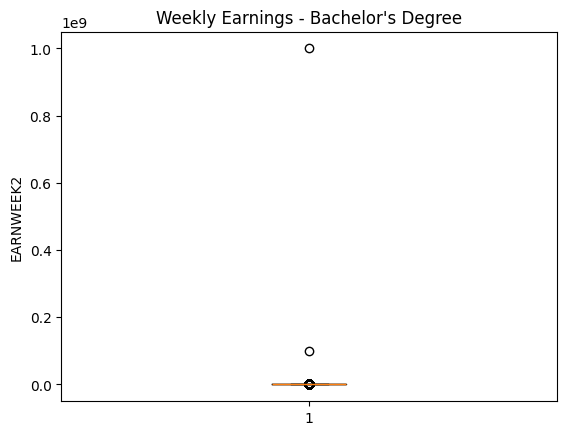

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(college_grads['EARNWEEK2'].dropna())
plt.title("Weekly Earnings - Bachelor's Degree")
plt.ylabel("EARNWEEK2")
plt.show()

Graduate Students

In [23]:
grad_students['EARNWEEK2'].describe(percentiles=[0.25, 0.5, 0.75])
grad_students['EARNWEEK2'].mean(), grad_students['EARNWEEK2'].median(), grad_students['EARNWEEK2'].std()

(np.float64(743231.8449401325), 999999.99, 436577.1221489499)

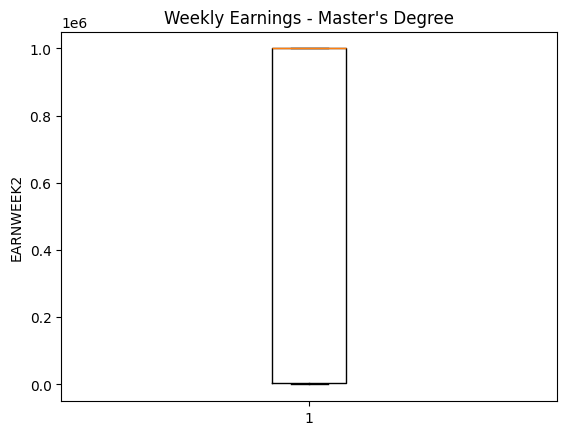

In [24]:
plt.figure()
plt.boxplot(grad_students['EARNWEEK2'].dropna())
plt.title("Weekly Earnings - Master's Degree")
plt.ylabel("EARNWEEK2")
plt.show()


The mean and median of graduate student group displays a higher earnings compared to college graduates in the graphs above. In the interquartile range and standard deviation have wider spreads showcasing variability. Depsite the graduate student group having higher earnings, they are also dispered

Earnings show much more variability than hours because hours worked has a limited range of what the employee can work as opposed to earnings which has a wider range/spread. The wider spread indicates with earnings suggests that there are other influences other than hours worked that affect it.


**Part D: Correlation Between Hours and Earnings**



For each education group:
a. Compute the correlation between UHRSWORKT and EARNWEEK2.
b. Using Matplotlib create a scatter plot of hours worked versus weekly earnings ensure it is
titled and axis are labeled.
c. In a text cell, interpret the relationship you observe.
Discuss:
• The strength of the relationship
• Whether hours worked appear to explain much of the variation in earnings

College Graduates

In [25]:
college_corr = college_grads[['UHRSWORKT', 'EARNWEEK2']].corr()
college_corr

,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.082505
EARNWEEK2,0.082505,1.000000


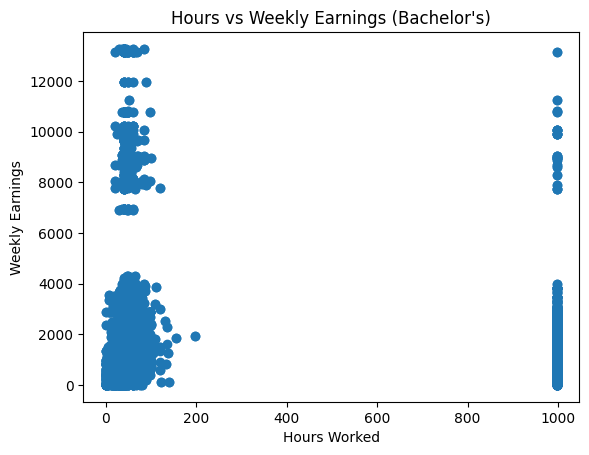

In [27]:
import numpy as np

# Create a temporary DataFrame for plotting to avoid modifying the original college_grads for other tasks
plot_data = college_grads[['UHRSWORKT', 'EARNWEEK2']].copy()

# Ensure UHRSWORKT is numeric, replacing non-convertible values with NaN
plot_data['UHRSWORKT'] = pd.to_numeric(plot_data['UHRSWORKT'], errors='coerce')
# Replace sentinel value 999 for UHRSWORKT with NaN
plot_data['UHRSWORKT'] = plot_data['UHRSWORKT'].replace(999, np.nan)

# EARNWEEK2 was previously converted to numeric and NaN filled with 0.0.
# If 0.0 earnings are also considered problematic or sentinel (from original 999999.99),
# replace them with NaN for a cleaner scatter plot that shows the actual relationship.
# We also re-replace 999999.99 just in case it was not fully handled earlier or for consistency.
plot_data['EARNWEEK2'] = plot_data['EARNWEEK2'].replace([0.0, 999999.99], np.nan)

# Drop rows where either UHRSWORKT or EARNWEEK2 is NaN
plot_data = plot_data.dropna(subset=['UHRSWORKT', 'EARNWEEK2'])

plt.figure()
plt.scatter(plot_data['UHRSWORKT'], plot_data['EARNWEEK2'])
plt.title("Hours vs Weekly Earnings (Bachelor's)")
plt.xlabel("Hours Worked")
plt.ylabel("Weekly Earnings")
plt.show()

In this graph we see that there's typically a positive relationship between the hours worked and earnings, but it is not a strong signal. There is a high variation and spread that suggests there are other factors influencing the positive relationship.



In [28]:
grad_corr = grad_students[['UHRSWORKT', 'EARNWEEK2']].corr()
grad_corr

,UHRSWORKT,EARNWEEK2
UHRSWORKT,1.000000,0.213764
EARNWEEK2,0.213764,1.000000


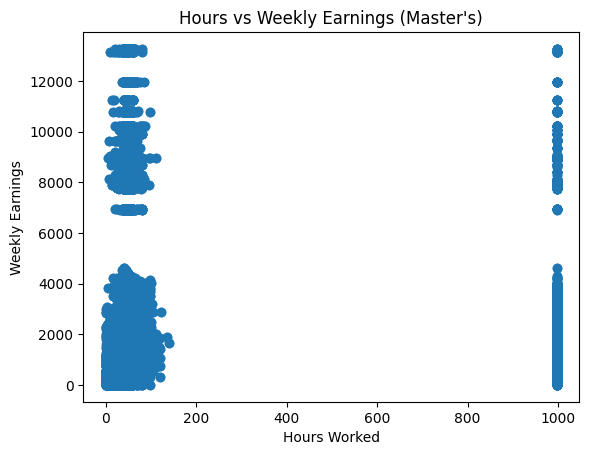

In [30]:
import numpy as np

# Create a temporary DataFrame for plotting to avoid modifying the original grad_students for other tasks
plot_data_grad = grad_students[['UHRSWORKT', 'EARNWEEK2']].copy()

# Ensure UHRSWORKT is numeric, replacing non-convertible values with NaN
plot_data_grad['UHRSWORKT'] = pd.to_numeric(plot_data_grad['UHRSWORKT'], errors='coerce')
# Replace sentinel value 999 for UHRSWORKT with NaN
plot_data_grad['UHRSWORKT'] = plot_data_grad['UHRSWORKT'].replace(999, np.nan)

# EARNWEEK2 was previously converted to numeric and NaN filled with 0.0.
# If 0.0 earnings are also considered problematic or sentinel (from original 999999.99),
# replace them with NaN for a cleaner scatter plot that shows the actual relationship.
# We also re-replace 999999.99 just in case it was not fully handled earlier or for consistency.
plot_data_grad['EARNWEEK2'] = plot_data_grad['EARNWEEK2'].replace([0.0, 999999.99], np.nan)

# Drop rows where either UHRSWORKT or EARNWEEK2 is NaN
plot_data_grad = plot_data_grad.dropna(subset=['UHRSWORKT', 'EARNWEEK2'])

plt.figure()
plt.scatter(plot_data_grad['UHRSWORKT'], plot_data_grad['EARNWEEK2'])
plt.title("Hours vs Weekly Earnings (Master's)")
plt.xlabel("Hours Worked")
plt.ylabel("Weekly Earnings")
plt.show()

**Part E: Reflection**

Part E: Reflection
In 3–5 sentences, respond to the following:
Which descriptive statistic (median, standard deviation, or correlation) was most useful
for comparing earnings across education groups, and why?
Your answer should reference results from earlier sections.

I think the standard deviation was most helpful because it allows the earnings to be shown for each group and how they are. The graudate student group had an extremely large standard deviation (436,577) and showed the widespread in earnings. The median was not relaible for interpreation because it had the top code of (999,999.99). I replaced values like 999999.99 in the code because they are placeholder numbers, not real earnings. I also converted 0.0 to NaN when it likely represented missing or invalid data. This was done to prevent skewed results that could disrupt the median. the This time it wasn't as helpful with showing the central data pattern. The standard devation provided a clear representation of the differences in earnings

